# Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import yfinance as yf
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,kpss
from scipy.stats import ks_2samp
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [69]:
import yfinance as yf
import pandas as pd

# Ticker symbol
ticker = "2222.SR"

# Create object
aramco = yf.Ticker(ticker)

# Historical data fetch (5 saal ka)
df = aramco.history(period="5y")

# Data preview
print(df.head())

# CSV me save karna ho to
df.to_csv("aramco_stock_data.csv")


                                Open       High        Low      Close  \
Date                                                                    
2021-02-15 00:00:00+03:00  22.695128  22.925036  22.695128  22.760815   
2021-02-16 00:00:00+03:00  22.760816  22.925037  22.760816  22.892193   
2021-02-17 00:00:00+03:00  22.925036  22.957879  22.760815  22.826504   
2021-02-18 00:00:00+03:00  22.826504  23.089254  22.793660  22.826504   
2021-02-21 00:00:00+03:00  22.826504  22.859348  22.760815  22.826504   

                            Volume  Dividends  Stock Splits  
Date                                                         
2021-02-15 00:00:00+03:00  4635824        0.0           0.0  
2021-02-16 00:00:00+03:00  3787210        0.0           0.0  
2021-02-17 00:00:00+03:00  3947335        0.0           0.0  
2021-02-18 00:00:00+03:00  8857618        0.0           0.0  
2021-02-21 00:00:00+03:00  3533345        0.0           0.0  


In [70]:
print(df.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [ ]:

df = df.reset_index()


print(df.columns)


df['Date'] = pd.to_datetime(df['Date'])

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='str')


In [72]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-02-15 00:00:00+03:00,22.695128,22.925036,22.695128,22.760815,4635824,0.0,0.0
1,2021-02-16 00:00:00+03:00,22.760816,22.925037,22.760816,22.892193,3787210,0.0,0.0
2,2021-02-17 00:00:00+03:00,22.925036,22.957879,22.760815,22.826504,3947335,0.0,0.0
3,2021-02-18 00:00:00+03:00,22.826504,23.089254,22.793660,22.826504,8857618,0.0,0.0
4,2021-02-21 00:00:00+03:00,22.826504,22.859348,22.760815,22.826504,3533345,0.0,0.0


In [73]:


df['Date'] = pd.to_datetime(df['Date'])


df['Date'] = df['Date'].dt.tz_localize(None)

In [74]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-02-15,22.695128,22.925036,22.695128,22.760815,4635824,0.0,0.0
1,2021-02-16,22.760816,22.925037,22.760816,22.892193,3787210,0.0,0.0
2,2021-02-17,22.925036,22.957879,22.760815,22.826504,3947335,0.0,0.0
3,2021-02-18,22.826504,23.089254,22.793660,22.826504,8857618,0.0,0.0
4,2021-02-21,22.826504,22.859348,22.760815,22.826504,3533345,0.0,0.0


In [75]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-02-15,22.695128,22.925036,22.695128,22.760815,4635824,0.0,0.0
1,2021-02-16,22.760816,22.925037,22.760816,22.892193,3787210,0.0,0.0
2,2021-02-17,22.925036,22.957879,22.760815,22.826504,3947335,0.0,0.0
3,2021-02-18,22.826504,23.089254,22.793660,22.826504,8857618,0.0,0.0
4,2021-02-21,22.826504,22.859348,22.760815,22.826504,3533345,0.0,0.0


In [76]:
df.tail(5)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
1244,2026-02-09,25.480000,25.680000,25.400000,25.680000,9717142,0.0,0.0
1245,2026-02-10,25.600000,25.860001,25.600000,25.860001,9803705,0.0,0.0
1246,2026-02-11,25.799999,25.840000,25.740000,25.820000,7296012,0.0,0.0
1247,2026-02-12,25.799999,26.000000,25.760000,26.000000,18734551,0.0,0.0
1248,2026-02-15,25.920000,25.980000,25.860001,25.860001,1660786,0.0,0.0


In [77]:
df.isnull().sum().sort_values(ascending=False)

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [78]:
df.shape

(1249, 8)

In [79]:
df.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1249,1249.000000,1249.000000,1249.000000,1249.000000,1.249000e+03,1249.000000,1249.000000
mean,2023-08-19 18:19:53,26.168885,26.311843,26.015318,26.165662,1.041316e+07,0.005446,0.001761
min,2021-02-15 00:00:00,22.596596,22.662283,22.530907,22.629438,0.000000e+00,0.000000,0.000000
25%,2022-05-19 00:00:00,24.329961,24.456530,24.216307,24.339697,4.650972e+06,0.000000,0.000000
50%,2023-08-23 00:00:00,25.620001,25.719150,25.461246,25.615459,7.918069e+06,0.000000,0.000000
75%,2024-11-20 00:00:00,27.928270,28.033604,27.764435,27.928270,1.262746e+07,0.000000,0.000000
max,2026-02-15 00:00:00,31.935475,32.574181,31.710047,31.935474,6.562831e+08,0.481500,1.100000
std,NaN,2.184112,2.222960,2.134097,2.176951,2.092425e+07,0.044922,0.044000


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   Date          1249 non-null   datetime64[s]
 1   Open          1249 non-null   float64      
 2   High          1249 non-null   float64      
 3   Low           1249 non-null   float64      
 4   Close         1249 non-null   float64      
 5   Volume        1249 non-null   int64        
 6   Dividends     1249 non-null   float64      
 7   Stock Splits  1249 non-null   float64      
dtypes: datetime64[s](1), float64(6), int64(1)
memory usage: 78.2 KB


# EDA 

In [81]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-02-15,22.695128,22.925036,22.695128,22.760815,4635824,0.0,0.0
1,2021-02-16,22.760816,22.925037,22.760816,22.892193,3787210,0.0,0.0
2,2021-02-17,22.925036,22.957879,22.760815,22.826504,3947335,0.0,0.0
3,2021-02-18,22.826504,23.089254,22.793660,22.826504,8857618,0.0,0.0
4,2021-02-21,22.826504,22.859348,22.760815,22.826504,3533345,0.0,0.0


In [82]:

df.columns = ['Date','Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='str')

In [83]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-02-15,22.695128,22.925036,22.695128,22.760815,4635824,0.0,0.0
1,2021-02-16,22.760816,22.925037,22.760816,22.892193,3787210,0.0,0.0
2,2021-02-17,22.925036,22.957879,22.760815,22.826504,3947335,0.0,0.0
3,2021-02-18,22.826504,23.089254,22.793660,22.826504,8857618,0.0,0.0
4,2021-02-21,22.826504,22.859348,22.760815,22.826504,3533345,0.0,0.0


In [84]:
import plotly.express as px

fig = px.line(
    df, 
    x='Date',                     
    y=['Open', 'High', 'Low', 'Close'], 
    title='ARAMCO Price Chart',
    markers=True,
    template='plotly_dark'
)

fig.update_layout(
    title=dict(x=0.5),
    xaxis_title='Date',
    yaxis_title='Price (SAR)'
)

fig.show()

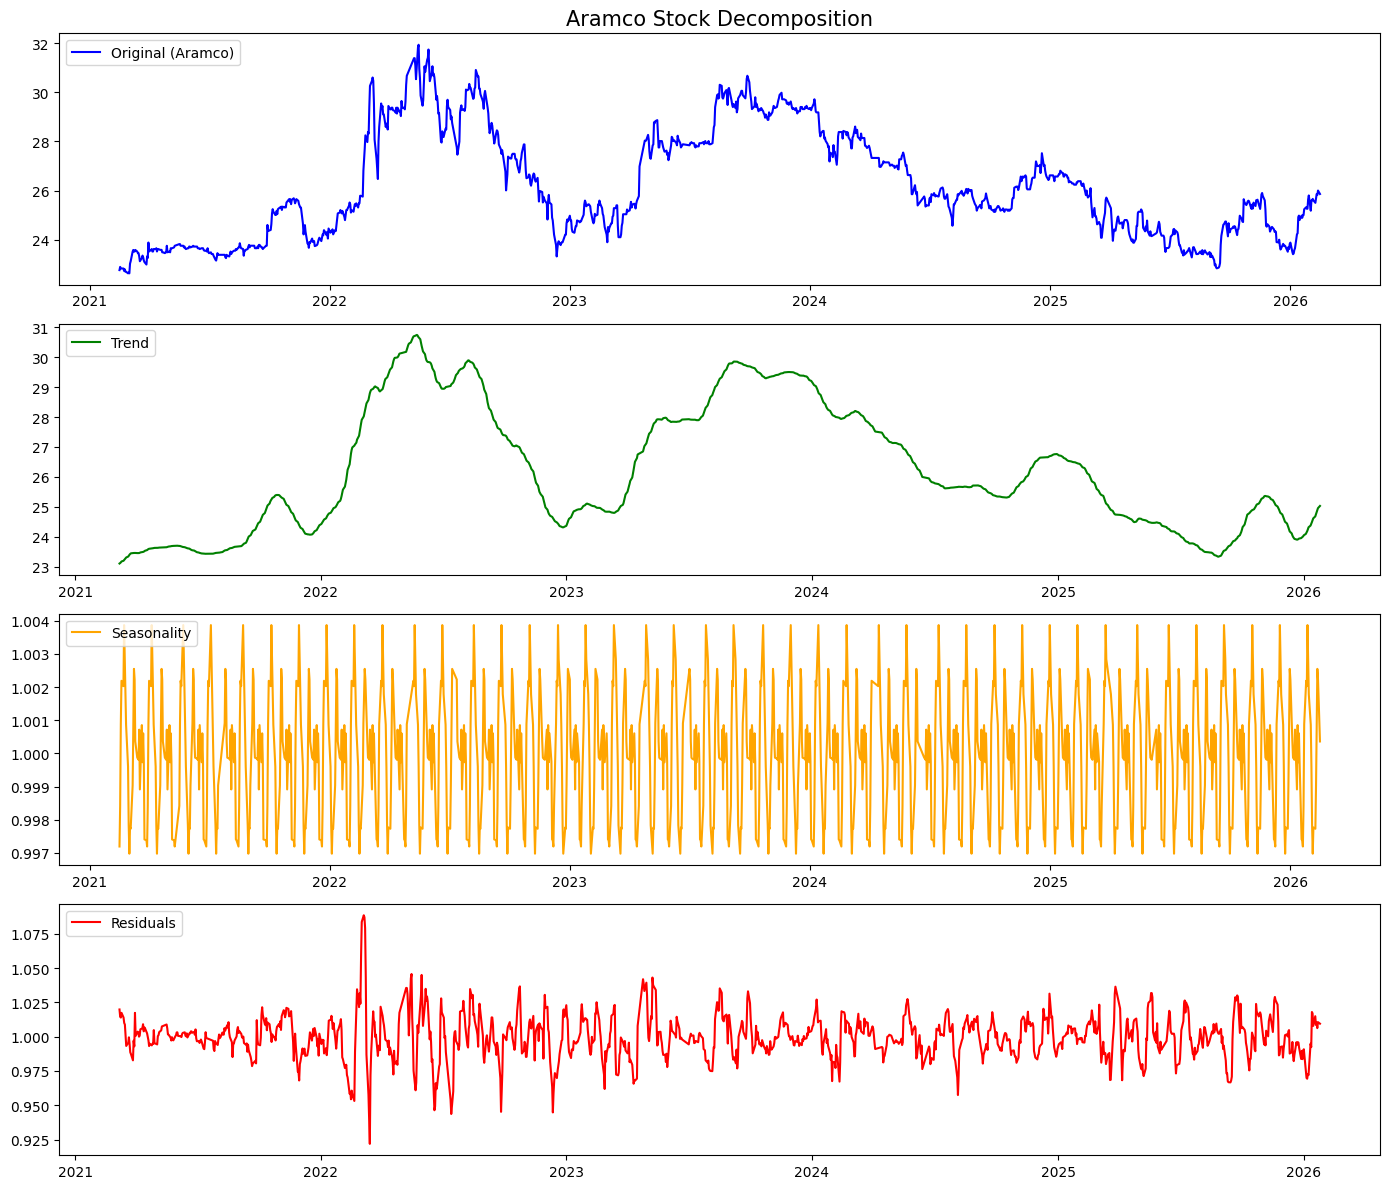

In [90]:



if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df.set_index('Date', inplace=True)


decompose = seasonal_decompose(df['Close'], model='multiplicative', period=30)

# 3. Plotting
plt.figure(figsize=(14, 12))

# Original
plt.subplot(411)
plt.plot(df['Close'], label='Original (Aramco)', color='Blue')
plt.title('Aramco Stock Decomposition', fontsize=15)
plt.legend(loc='upper left')

# Trend (Market ka long-term direction)
plt.subplot(412)
plt.plot(decompose.trend, label='Trend', color='Green')
plt.legend(loc='upper left')

# Seasonality (Periodic patterns)
plt.subplot(413)
plt.plot(decompose.seasonal, label='Seasonality', color='Orange')
plt.legend(loc='upper left')

# Residuals (Random noise/Unexpected events)
plt.subplot(414)
plt.plot(decompose.resid, label='Residuals', color='Red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Trend (Green)
## Observation: The trend shows a sharp peak in early 2022, reaching approximately 32 SAR, followed by a gradual correction and consolidation between 24 and 26 SAR through 2023 and 2024.

## Insight: This indicates a non-linear, long-term bearish correction after a major bullish run. Standard Linear Regression might struggle here; non-linear models like Random Forest or XGBoost would be more effective for this type of movement.

# Seasonality (Orange)
## Observation: A very distinct, consistent, and high-frequency wave pattern is visible, repeating every 30 days (due to the period=30 setting).

## Insight: This confirms strong monthly seasonality in Aramco's stock. The price follows a predictable cycle within each month, likely driven by recurring factors such as monthly oil production data or institutional trading cycles.

# Residuals (Red)
## Observation: The residuals (noise) show significant spikes and "bursts" of volatility, especially during periods of rapid price change.

## Insight: These residuals represent "Black Swan" events or unexpected market news that the trend and seasonality cannot explain. The presence of these spikes suggests that the model's error might increase during major geopolitical or economic announcements.

# Stationarity

In [94]:
adf_test=adfuller(df['Close'])
print("ADF Test Results")
print(f"ADF Statistic: {adf_test[0]}")
print(f"P-value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
 print(f" {key}: {value}")
if adf_test[1] < 0.05:
 print("\nStationary Data")
else:
 print("\n Non Stationary Data")

ADF Test Results
ADF Statistic: -2.240929273584791
P-value: 0.19172712741805137
Critical Values:
 1%: -3.4356260602190356
 5%: -2.863869899335344
 10%: -2.5680104683371323

 Non Stationary Data


# ADF Test AnalysisObservation:
 ##  ADF Statistic is -2.24. For most financial time series, the 5% critical value is around -2.86 and the 1% value is around -3.43.Insight: Since $-2.24$ is greater (less negative) than the critical values, we fail to reject the Null Hypothesis ($H_0$). This means your data is non-stationary.

In [95]:
kpss_test=kpss(df['Close'],regression='ct',nlags="auto")
print("\nKPSS Test Results")
print(f"KPSS Statistic: {kpss_test[0]}")
print(f"P-value: {kpss_test[1]}")
print("Critical Values:")
for key, value in kpss_test[3].items():
 print(f" {key}: {value}")
if kpss_test[1] < 0.05:
 print("\n Non Stationary Data")
else:
 print("\nStationary Data")


KPSS Test Results
KPSS Statistic: 0.794193736771307
P-value: 0.01
Critical Values:
 10%: 0.119
 5%: 0.146
 2.5%: 0.176
 1%: 0.216

 Non Stationary Data


Since the data is not stationary based on both the ADF and KPSS tests, it also fails the KS
test.
Therefore, we need to convert the data into a stationary form before proceeding further.
To achieve stationarity, we have four standard methods:
1. Differencing
2. Transformation
3. Detrending
4. Seasonality Adjustment 

In [ ]:
def adf_check(series):
    result = adfuller(series)
    print("ADF Test Results")
    print(f"ADF Statistic: {result[0]}")
    print(f"P-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value}")  # Line 7: Added indentation here
    
    if result[1] < 0.05:
        print("Stationary Data")
    else:
        print("Non Stationary Data")

def kpss_check(series):
 
    result = kpss(series, regression='c', nlags="auto")
    print("\nKPSS Test Results")
    print(f"KPSS Statistic: {result[0]}")
    print(f"P-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[3].items():
        print(f"  {key}: {value}") # Added indentation here
        
    if result[1] < 0.05:
        print("Non Stationary Data")
    else:
        print("Stationary Data")

In [98]:
prices = df['Close'].diff().dropna()
adf_check(prices)
kpss_check(prices)

ADF Test Results
ADF Statistic: -16.989085152165295
P-value: 8.896469107953021e-30
Critical Values:
  1%: -3.4356260602190356
  5%: -2.863869899335344
  10%: -2.5680104683371323
Stationary Data

KPSS Test Results
KPSS Statistic: 0.10336339760087897
P-value: 0.1
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
Stationary Data


In [99]:
mid=len(prices)//2
first_half = prices.iloc[:mid]
second_half = prices.iloc[mid:]
ks_stat, p_value = ks_2samp(first_half, second_half)
print("KS Statistic:", ks_stat)
print("P-value:", p_value)
if p_value > 0.05:
 print("Distributions are similar so Strict stationarity holds")
else:
 print("Distributions differ so Strict stationarity violated")

KS Statistic: 0.07371794871794872
P-value: 0.06732187086565075
Distributions are similar so Strict stationarity holds


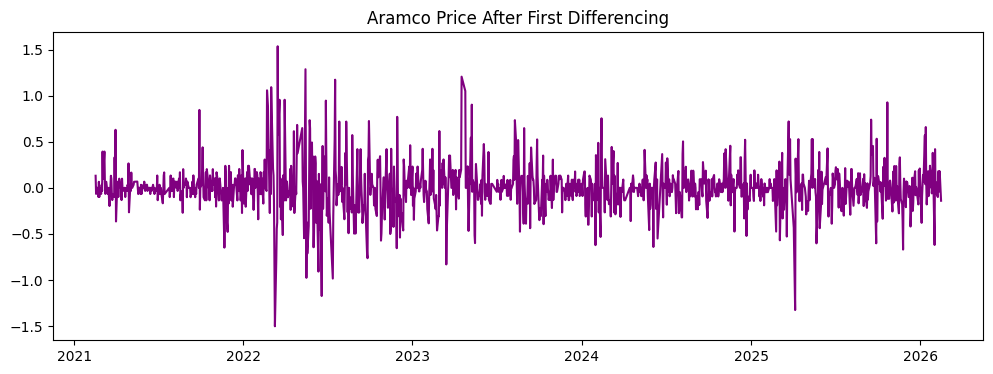

In [100]:
df['Close_Diff'] = df['Close'].diff()

df_diff = df.dropna()

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df_diff['Close_Diff'], color='purple')
plt.title('Aramco Price After First Differencing')
plt.show()

In [101]:
lb_test = acorr_ljungbox(prices, lags=[10,20,30], return_df=True)
print("Ljung-Box Test Results (Differenced Prices):")
print(lb_test)

Ljung-Box Test Results (Differenced Prices):
      lb_stat     lb_pvalue
10  62.926104  1.008524e-09
20  81.940228  1.834558e-09
30  92.966696  2.315485e-08


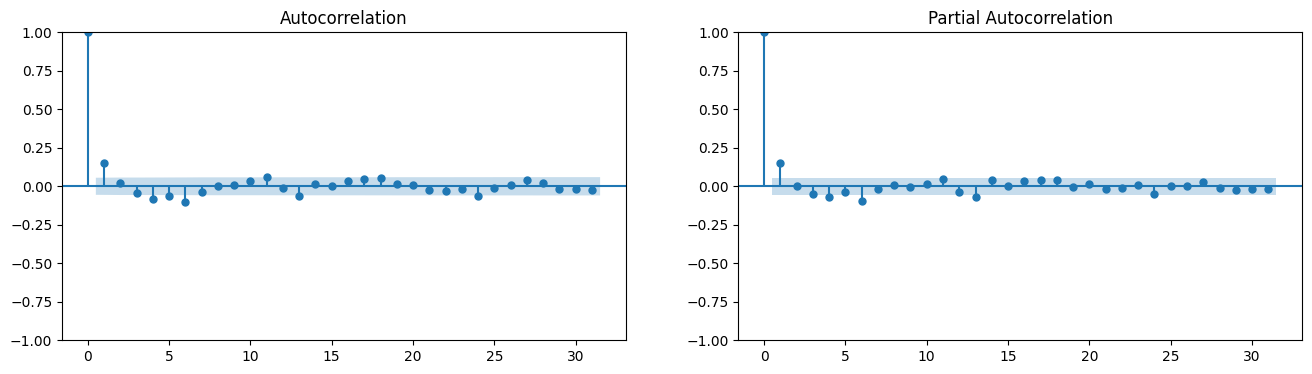

In [102]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff['Close_Diff'], ax=ax[0])
plot_pacf(df_diff['Close_Diff'], ax=ax[1])
plt.show()

## Now we will use our series to try 5 univariate time series models:
### . AR (Autoregressive)
### . MA (Moving Average)
### . ARMA (Autoregressive Moving Average)
### . ARIMA (Autoregressive Integrated Moving Average)
### . SARIMA (Seasonal ARIMA)

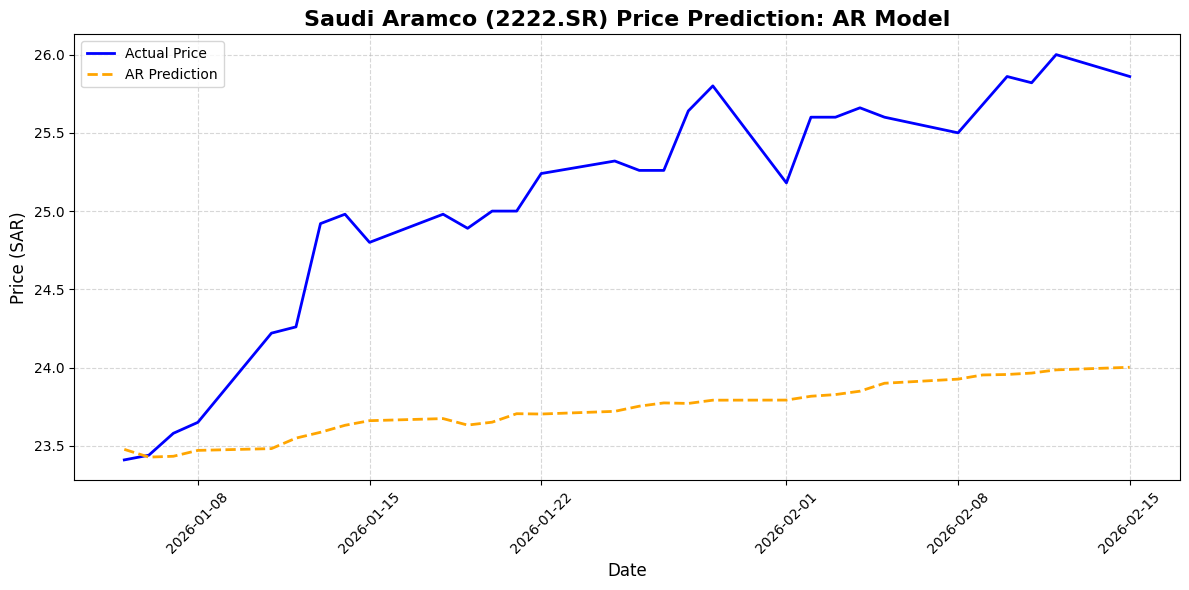

In [105]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(train_data, lags=30)
model_fit = model.fit()


predictions = model_fit.predict(
    start=len(train_data), 
    end=len(train_data) + len(test_data) - 1, 
    dynamic=False
)


predictions_clean = predictions.ffill() 


plt.figure(figsize=(12,6))

# Actual vs Predicted
plt.plot(test_data.index, test_data, label='Actual Price', color='blue', linewidth=2)
plt.plot(test_data.index, predictions_clean, label='AR Prediction', color='orange', linestyle='--', linewidth=2)

# Formatting
plt.title('Saudi Aramco (2222.SR) Price Prediction: AR Model', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (SAR)', fontsize=12) # Aramco currency SAR mein hai
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

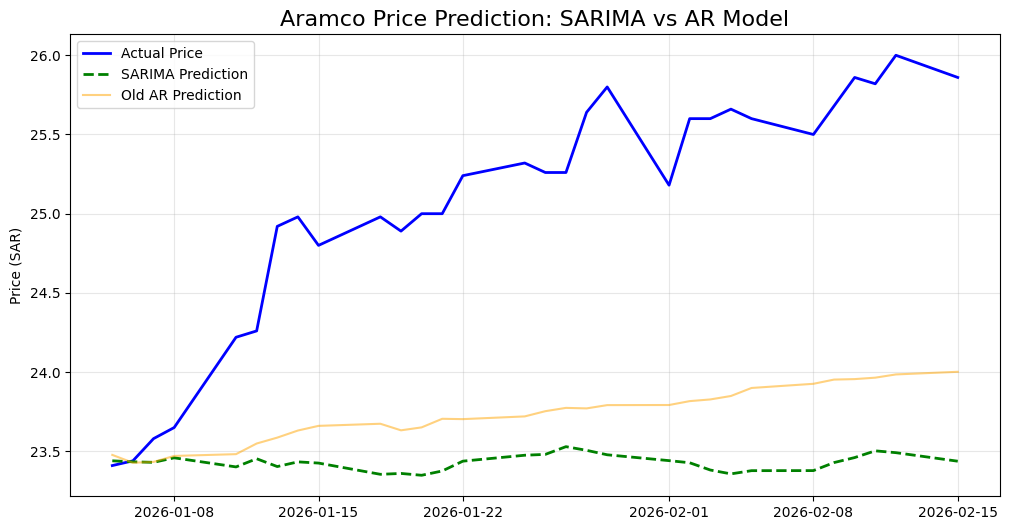

In [106]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model_sarima = SARIMAX(train_data, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 30))

model_fit_sarima = model_sarima.fit(disp=False)

# 2. Prediction (30 Days)
sarima_pred = model_fit_sarima.get_forecast(steps=30).predicted_mean

# 3. Plotting
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data, label='Actual Price', color='blue', linewidth=2)
plt.plot(test_data.index, sarima_pred, label='SARIMA Prediction', color='green', linestyle='--', linewidth=2)
plt.plot(test_data.index, predictions_clean, label='Old AR Prediction', color='orange', alpha=0.5)

plt.title('Aramco Price Prediction: SARIMA vs AR Model', fontsize=16)
plt.ylabel('Price (SAR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [107]:
import pmdarima as pm
auto_model = pm.auto_arima(train_data, 
                          seasonal=True, m=30, # 30-day seasonality
                          stepwise=True, 
                          suppress_warnings=True, 
                          error_action="ignore", 
                          max_p=5, max_q=5, 
                          trace=True)

print(auto_model.summary())

# Prediction
forecast_final = auto_model.predict(n_periods=30)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[30] intercept   : AIC=141.240, Time=27.84 sec
 ARIMA(0,1,0)(0,0,0)[30] intercept   : AIC=178.962, Time=0.31 sec
 ARIMA(1,1,0)(1,0,0)[30] intercept   : AIC=152.401, Time=2.82 sec
 ARIMA(0,1,1)(0,0,1)[30] intercept   : AIC=153.292, Time=2.77 sec
 ARIMA(0,1,0)(0,0,0)[30]             : AIC=176.968, Time=0.09 sec
 ARIMA(2,1,2)(0,0,1)[30] intercept   : AIC=139.729, Time=21.75 sec
 ARIMA(2,1,2)(0,0,0)[30] intercept   : AIC=137.978, Time=1.86 sec
 ARIMA(2,1,2)(1,0,0)[30] intercept   : AIC=139.718, Time=22.39 sec
 ARIMA(1,1,2)(0,0,0)[30] intercept   : AIC=149.742, Time=1.85 sec
 ARIMA(2,1,1)(0,0,0)[30] intercept   : AIC=154.552, Time=0.51 sec
 ARIMA(3,1,2)(0,0,0)[30] intercept   : AIC=140.313, Time=3.13 sec
 ARIMA(2,1,3)(0,0,0)[30] intercept   : AIC=141.899, Time=3.34 sec
 ARIMA(1,1,1)(0,0,0)[30] intercept   : AIC=152.541, Time=0.22 sec
 ARIMA(1,1,3)(0,0,0)[30] intercept   : AIC=144.114, Time=2.45 sec
 ARIMA(3,1,1)(0,0,0)[30] inter

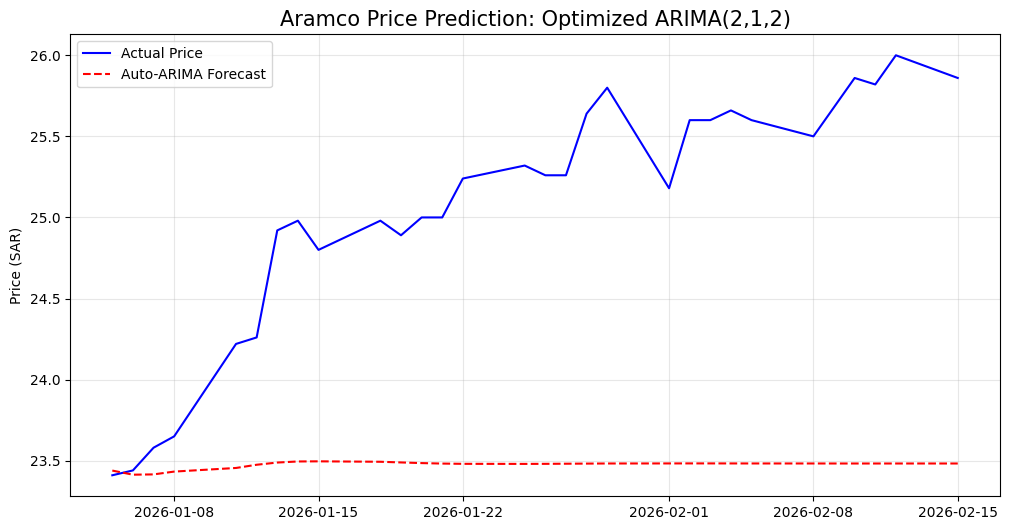

In [108]:

forecast_results = auto_model.predict(n_periods=30)

# 2. Plotting
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data, label='Actual Price', color='blue')
plt.plot(test_data.index, forecast_results, label='Auto-ARIMA Forecast', color='red', linestyle='--')
plt.title('Aramco Price Prediction: Optimized ARIMA(2,1,2)', fontsize=15)
plt.ylabel('Price (SAR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [110]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_data.values.reshape(-1,1))

X_train, y_train = [], []
for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i, 0])
    y_train.append(scaled_train[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
# Model input format: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    # P
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2), 
    
    Dropout(0.2),
    
    Dense(units=1) 
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=25, batch_size=32)

2026-02-15 09:14:34.922246: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0342
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0070
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0063
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0063
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0059
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0055
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0054
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0052
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0051
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0050
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0046
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0048
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0045
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0047
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0044

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step


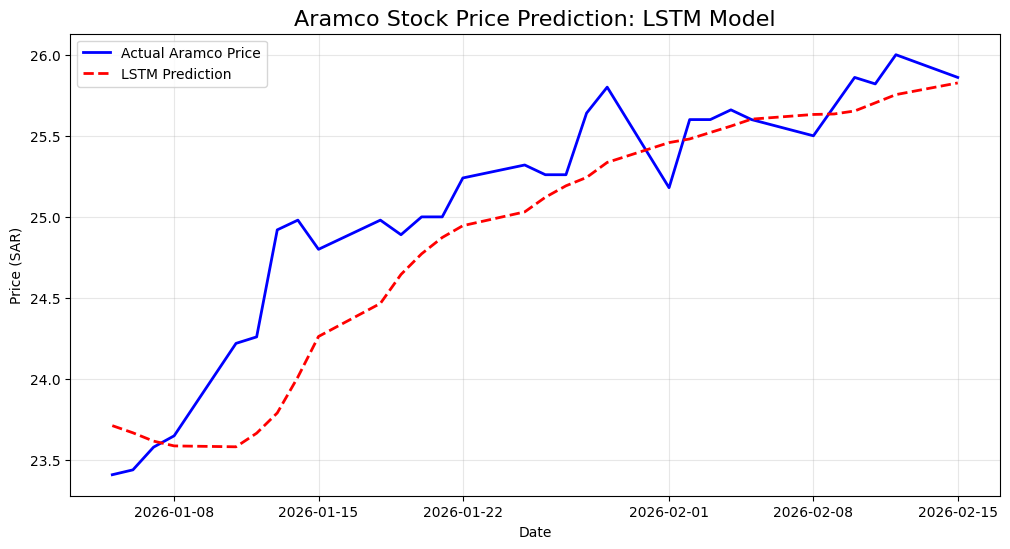

In [ ]:

all_data = prices.values.reshape(-1,1)
scaled_all_data = scaler.transform(all_data)

X_test_final = []
for i in range(len(scaled_all_data) - 30, len(scaled_all_data)):
    X_test_final.append(scaled_all_data[i-60:i, 0])

X_test_final = np.array(X_test_final)
X_test_final = np.reshape(X_test_final, (X_test_final.shape[0], X_test_final.shape[1], 1))

# 2. Prediction karein
lstm_predictions = model.predict(X_test_final)
lstm_predictions = scaler.inverse_transform(lstm_predictions) # Wapas SAR mein convert karein

# 3. Plotting
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data.values, label='Actual Aramco Price', color='blue', linewidth=2)
plt.plot(test_data.index, lstm_predictions, label='LSTM Prediction', color='red', linestyle='--', linewidth=2)

plt.title('Aramco Stock Price Prediction: LSTM Model', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (SAR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Metrics Calculate
rmse = np.sqrt(mean_squared_error(test_data, lstm_predictions))
mae = mean_absolute_error(test_data, lstm_predictions)

print(f"LSTM Root Mean Squared Error (RMSE): {rmse:.4f} SAR")
print(f"LSTM Mean Absolute Error (MAE): {mae:.4f} SAR")

LSTM Root Mean Squared Error (RMSE): 0.3921 SAR
LSTM Mean Absolute Error (MAE): 0.2874 SAR


In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model_gru.compile(optimizer='adam', loss='mean_squared_error')
model_gru.fit(X_train, y_train, epochs=25, batch_size=32)

# GRU Prediction
gru_predictions = model_gru.predict(X_test_final)
gru_predictions = scaler.inverse_transform(gru_predictions)

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0213
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0048
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0045
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0044
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0038
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0043
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - loss: 0.0036
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0032
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0031
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - loss: 0.0033
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0028
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0027
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0031
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0031
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss:

GRU Root Mean Squared Error (RMSE): 0.3056 SAR
GRU Mean Absolute Error (MAE): 0.2437 SAR


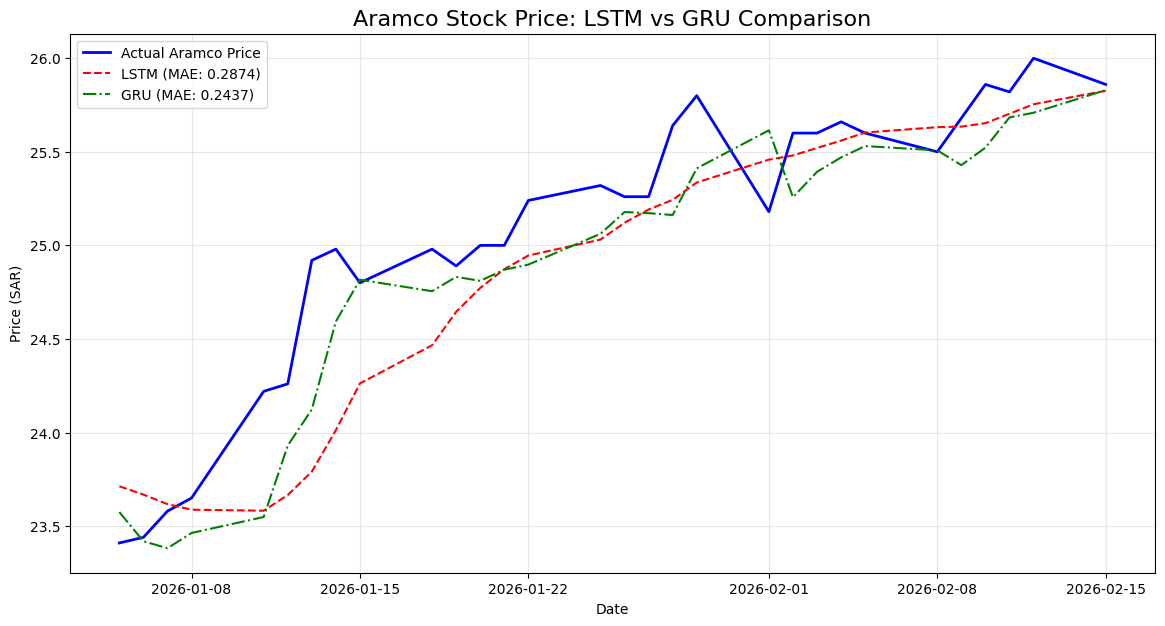

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


rmse_gru = np.sqrt(mean_squared_error(test_data, gru_predictions))
mae_gru = mean_absolute_error(test_data, gru_predictions)

print(f"GRU Root Mean Squared Error (RMSE): {rmse_gru:.4f} SAR")
print(f"GRU Mean Absolute Error (MAE): {mae_gru:.4f} SAR")

plt.figure(figsize=(14,7))
plt.plot(test_data.index, test_data.values, label='Actual Aramco Price', color='blue', linewidth=2)
plt.plot(test_data.index, lstm_predictions, label=f'LSTM (MAE: {mae:.4f})', color='red', linestyle='--')
plt.plot(test_data.index, gru_predictions, label=f'GRU (MAE: {mae_gru:.4f})', color='green', linestyle='-.')

plt.title('Aramco Stock Price: LSTM vs GRU Comparison', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (SAR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

last_60_days = scaled_all_data[-60:]
current_batch = last_60_days.reshape((1, 60, 1))

future_predictions = []


for i in range(7):
    
    current_pred = model_gru.predict(current_batch)[0]
    future_predictions.append(current_pred)
    
    
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)


future_predictions_sar = scaler.inverse_transform(future_predictions)


import pandas as pd
last_date = test_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# 5. Result Table
future_df = pd.DataFrame(data=future_predictions_sar, index=future_dates, columns=['Predicted_Price'])
print("Aramco Future Price Predictions (Next 7 Days):")
print(future_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Aramco Future Price Predictions (Next 7 Days):
            Predicted_Price
2026-02-16        25.775650
2026-02-17        25.692717
2026-02-18        25.611740
2026-02-19        25.534429
2026-02-20        25.460344
2026-02-21        25.388836
2026-02-22        25.319358


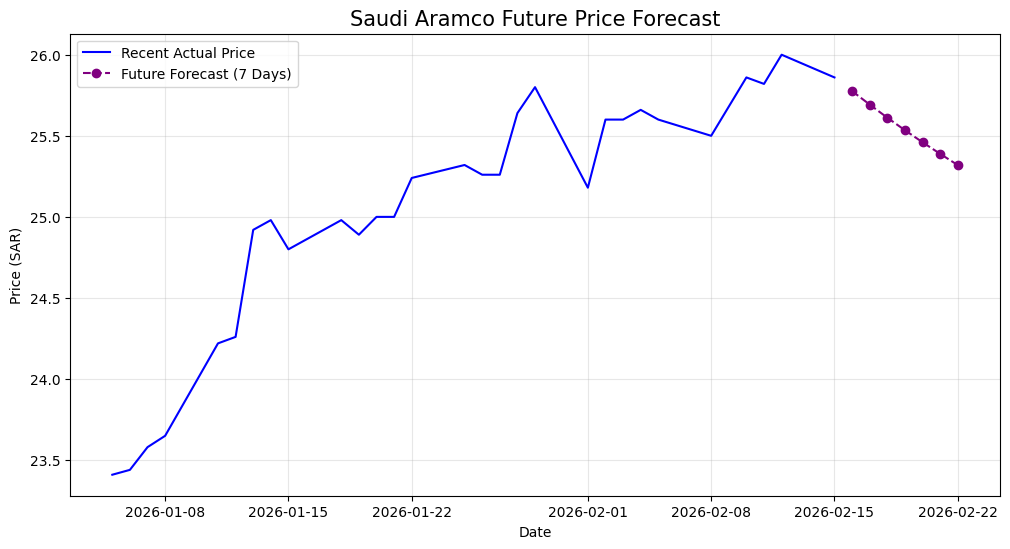

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test_data.index, test_data.values, label='Recent Actual Price', color='blue')

plt.plot(future_dates, future_predictions_sar, label='Future Forecast (7 Days)', color='purple', marker='o', linestyle='--')

plt.title('Saudi Aramco Future Price Forecast', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price (SAR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()